<a href="https://colab.research.google.com/github/CristianIDL/cifar10-mlp-practice/blob/main/A20_CIFAR10_MLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Clasificación de imágenes CIFAR-10 mediante MLP

### Redes Neuronales y Aprendizaje Profundo
Delgado Lucero Cristian Isaac 6BV1

## Sección 1. Introducción

En esta práctica se utilizará el conjunto de datos CIFAR-10, el cual contiene imágenes a color de tamaño 32×32 píxeles pertenecientes a diez categorías diferentes:
- avión
- automóvil
- pájaro
- gato
- venado
- perro
- rana
- caballo
- barco
- camión.

El objetivo consiste en desarrollar un clasificador basado en una red neuronal multicapa (MLP, Multi-Layer Perceptron) capaz de identificar la categoría correspondiente a cada imagen. Debido a las restricciones de la actividad, no se utilizarán Redes Neuronales Convolucionales (CNN), por lo que las imágenes deberán adaptarse para ser procesadas por una arquitectura completamente conectada.

Durante el desarrollo se realizarán diferentes experimentos modificando la arquitectura y los hiperparámetros del modelo con el propósito de comparar su desempeño y seleccionar la mejor configuración utilizando evidencia empírica. Para ello se analizarán métricas de entrenamiento, validación y prueba, así como gráficas de desempeño y matrices de confusión.

## Objetivos
- Cargar y preparar correctamente el conjunto de datos CIFAR-10.
- Adaptar las imágenes para su procesamiento mediante un MLP.
- Implementar y entrenar múltiples configuraciones de redes neuronales.
- Comparar el desempeño de los modelos obtenidos.
- Seleccionar y justificar la mejor arquitectura con base en resultados experimentales.

## Sección 2: Librerías

`TensorFlow` y `Keras` Será nuestro framework principal para construir las redes neuronales.

Lo utilizaremos para:

1. Descargar CIFAR-10.
2. Crear modelos MLP.
3. Entrenar la red.
4. Evaluar resultados.

Igualmente utilizaremos: `Numpy`, `Matplotlib` y `Scikit-Learn`.

In [ ]:
# Importación de librerías
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))

from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical

In [ ]:
# Semillita parar reproducibilidad
np.random.seed(42)
tf.random.set_seed(42)

In [ ]:
# Comprobamos las versiones
print("TensorFlow: ", tf.__version__)
print("Numpy: ", np.__version__)

## Sección 3: Dataset CIFAR-10

Keras ya tiene una división predefinida:

```
Entrenamiento: 50,000 imágenes

Prueba: 10,000 imágenes
```

Cada imagen tiene estas dimensiones:

```
32 × 32 × 3

donde:

32 = ancho
32 = alto
3 = canales RGB
```

In [ ]:
# Importamos la drive para acceder al dataset sin reinstalarlo
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
# Cargamos CIFAR-10 de mi Drive
data = np.load(
    "/content/drive/MyDrive/datasets/CIFAR10/cifar10.npz"
)

X_train_full = data["X_train"]
y_train_full = data["y_train"]

X_test = data["X_test"]
y_test = data["y_test"]

In [ ]:
print("X_train_full:", X_train_full.shape)
print("y_train_full:", y_train_full.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

Los resultados de `X_train_full` indican lo siguiente: `X_train_full: (50000, 32, 32, 3)`

Que representa 50000 imágenes donde cada imagen tiene:

```
    - 32 píxeles de alto
    - 32 píxeles de ancho
    - 3 canales de color
```

# Sección 4: Exploración del Dataset
Antes de entrenar la red neuronal es importante analizar la estructura del conjunto de datos. En esta sección visualizaremos ejemplos de imágenes, las dimensiones de los tensores y la distribución de las clases para verificar que los datos fueron cargados correctamente.

In [ ]:
# Definimos los nombres de las clases
class_names = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck"
]

In [ ]:
# Inspeccionamos el contenido del dataset

plt.figure(figsize=(12,6))

for i in range(10):
  plt.subplot(2,5,i+1)
  plt.imshow(X_train_full[i])
  plt.title(class_names[y_train_full[i][0]])
  plt.axis('off')

plt.tight_layout()
plt.show()

Se observa que las imágenes poseen una resolución reducida (32×32 píxeles) y presentan variaciones importantes en color, iluminación y perspectiva. Estas características aumentan la complejidad de la tarea de clasificación.

In [ ]:
# Contamos la cantidad de ejemplos que tenemos de cada clase
unique, counts = np.unique(y_train_full, return_counts=True)

for clase, cantidad in zip(unique, counts):
  print(class_names[clase], ":", cantidad)

In [ ]:
# Graficamos el histograma
plt.figure(figsize=(10,5))

plt.bar([class_names[i] for i in unique], counts)

plt.xticks(rotation=45)
plt.ylabel("Cantidad de imágenes")
plt.title("Distribución de clases")
plt.show()

El conjunto de datos presenta una distribución balanceada entre las diez categorías, por lo que no se espera que el modelo favorezca una clase debido a una mayor cantidad de ejemplos.

In [ ]:
# Hay que comprender el tensor de la imagen
imagen = X_train_full[0]

print("Dimensión: ", imagen.shape)

print("Valores del primer píxel RGB: ", imagen[0,0])

Cuando alimentemos nuestro MPL estarémos convirtiendo esos (32, 32, 3) en características con `reshape(-1,3072)`

## Sección 3: Dividir clases en conjuntos

### División de los datos

Dividiremos el conjunto de entrenamiento original en dos subconjuntos: entrenamiento y validación.

Como ya hemos visto en otras prácticas: El conjunto de entrenamiento será utilizado para ajustar los pesos de la red neuronal, mientras que el conjunto de validación permitirá comparar diferentes arquitecturas e hiperparámetros sin utilizar el conjunto de prueba.

El conjunto de prueba permanecerá reservado para la evaluación final del mejor modelo seleccionado.

In [ ]:
# División Train-Validation

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size = 0.20,
    random_state = 42,
    stratify = y_train_full # misma proporión de clases en ambos conjuntos
)

print("--- Verificamos los tamaños ---")
print("\tTrain: ", X_train.shape)
print("\tValidation: ", X_val.shape)
print("\tTest: ", X_test.shape)

print("\n--- Verificamos los targets ---")
print("\ty_train: ", y_train.shape)
print("\ty_validation: ", y_val.shape)
print("\ty_test: ", y_test.shape)



In [ ]:
# Verificamos el balance de las clasaes
unique_train, counts_train = np.unique(y_train, return_counts=True)
unique_val, counts_val = np.unique(y_val, return_counts=True)

# Visualizamos
plt.figure(figsize=(12,5))

# Graficas entrenamiento
plt.subplot(1,2,1)
plt.bar(
  [class_names[i] for i in unique_train],
  counts_train
)
plt.title("Train")
plt.xticks(rotation=45) # el texto de las etiquetas rotado poquito

# Graficas validation
plt.subplot(1,2,2)
plt.bar(
    [class_names[i] for i in unique_val],
    counts_val
)
plt.title("Validation")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Resultados de la división

La división se realizó preservando la distribución original de las clases mediante estratificación. Se obtuvieron 40,000 imágenes para entrenamiento, 10,000 para validación y 10,000 para prueba.

Esta separación permitirá entrenar distintos modelos, comparar su desempeño utilizando el conjunto de validación y finalmente evaluar el mejor modelo sobre datos completamente no vistos.

In [ ]:
print("Resumen de conjuntos")
print("-" * 30)

print(f"Train      : {X_train.shape}")
print(f"Validation : {X_val.shape}")
print(f"Test       : {X_test.shape}")

print()

print(f"y_train    : {y_train.shape}")
print(f"y_val      : {y_val.shape}")
print(f"y_test     : {y_test.shape}")

## Preprocesamiento de los datos

Las imágenes de CIFAR-10 se encuentran almacenadas como tensores tridimensionales de tamaño 32×32×3. Debido a que un perceptrón multicapa trabaja con vectores de características, es necesario transformar cada imagen en un vector unidimensional.

```
32*32*3 = 3072

Imagen RGB
      ↓
Vector de 3072 valores
```

Posteriormente se normalizarán los valores de los píxeles y se convertirá la variable objetivo a codificación one-hot para facilitar el entrenamiento de la red neuronal.

In [ ]:
# Aplanamos los valores
X_train = X_train.reshape(-1, 3072)
X_val   = X_val.reshape(-1, 3072)
X_test  = X_test.reshape(-1, 3072)

# El -1 infiera automáticamente la dimensión

# Mostramos los valores
print("Train: ", X_train.shape)
print("Validation: ", X_val.shape)
print("Test: ", X_test.shape)

In [ ]:
# Conversión a float32

print("Tipo de dato original: ", X_train.dtype)

X_train = X_train.astype("float32")
X_val   = X_val.astype("float32")
X_test  = X_test.astype("float32")

print("Tipo de dato transformado: ",X_train.dtype)

In [ ]:
# Comprobamos valores entre 0 y 255
print(X_train.min())
print(X_train.max())

### Normalización

Por qué normalizamos?
Las redes neuronales suelen converger más rápido cuando los datos están en escalas pequeñas.

In [ ]:
# Normalización
X_train /= 255.0
X_val   /= 255.0
X_test  /= 255.0

# Verificamos
print(X_train.min())
print(X_train.max())

### One-Hot-Encoding

In [ ]:
# Estado actual de las etiquetas
print(y_train[0], " = Clase de y_train[0] = ", class_names[y_train[0][0]])

Como la salida de nuestra red tendrá: `10 neuronas`

Necesitamos transformar `[6]` en `[0 0 0 0 0 0 1 0 0 0]`

In [ ]:
# Usamos to_categorical
y_train = to_categorical(y_train, 10)
y_val   = to_categorical(y_val, 10)
y_test  = to_categorical(y_test, 10)

print("Clase de y_train[0] one-hot= ", y_train[0])

In [ ]:
# Inspeccionamos los datos

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

print("\ny_train:", y_train.shape)
print("y_val:", y_val.shape)
print("y_test:", y_test.shape)

### Resultados del preprocesamiento

Las imágenes fueron transformadas de tensores tridimensionales de tamaño 32×32×3 a vectores unidimensionales de 3072 características. Posteriormente se normalizaron los valores de los píxeles al intervalo [0,1] y las etiquetas fueron convertidas a codificación one-hot.

Con ello los datos quedan preparados para ser utilizados por una red neuronal multicapa (MLP).

## Implementación del Modelo Base (Baseline)

Una vez completado el preprocesamiento de los datos, se procede a construir el primer clasificador basado en un Perceptrón Multicapa (MLP).

La función de este modelo es servir como línea base para los experimentos posteriores. Su desempeño permitirá establecer un punto de comparación al modificar la arquitectura o los hiperparámetros en configuraciones más avanzadas.

Debido a que las imágenes fueron transformadas en vectores de 3072 características, la capa de entrada recibirá un vector de dicha longitud. Posteriormente se utilizarán capas densamente conectadas para aprender representaciones internas de los datos hasta producir una predicción sobre las diez categorías de CIFAR-10.

La capa de salida utilizará la función de activación Softmax, ya que el problema corresponde a una clasificación multiclase mutuamente excluyente. De esta forma, la red generará una distribución de probabilidades sobre las diez clases posibles.

Adicionalmente se incorporará Dropout como mecanismo de regularización para reducir el riesgo de sobreajuste durante el entrenamiento.


In [ ]:
# Cálculo de parámetros con 512 neuronas ocultas

input_features = 3072
hidden_neurons = 512

# El bias es el +1
params = (input_features + 1) * hidden_neurons

print(f"Parámetros primera capa: {params:,}")

# Construcción del Modelo A

Arquitectura propuesta:

```
Entrada (3072)
↓
Dense(512)
ReLU
↓
Dropout(0.3)
↓
Dense(256)
ReLU
↓
Dense(10)
Softmax
```

In [ ]:
# Importamos librerías
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

In [ ]:
from sys import activate_stack_trampoline
# Creamos el modelo

model_a = Sequential([
    Dense(
        512,
        activation = "relu",
        input_shape = (3072,)
    ),

    Dropout(0.3),

    Dense(
        256,
        activation = "relu"
    ),

    Dense(
        10,
        activation="softmax"
    )
])

In [ ]:
# Compilación del modelo
model_a.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Verificamos antes de entrenar
print("Forma de entrada:", X_train.shape)
print("Forma de salida:", y_train.shape, "\n")

model_a.summary()

## Entrenamiento del Modelo Base

Una vez definida la arquitectura de la red neuronal, se procede al proceso de entrenamiento utilizando el conjunto de entrenamiento previamente preparado.

Durante el entrenamiento, la red ajustará sus pesos mediante retropropagación del error con el objetivo de minimizar la función de pérdida categórica. Para monitorear el comportamiento del modelo se utilizará el conjunto de validación, permitiendo detectar posibles problemas de sobreajuste o subajuste.

Adicionalmente se empleará la técnica de Early Stopping, la cual detiene automáticamente el entrenamiento cuando el desempeño sobre el conjunto de validación deja de mejorar durante varias épocas consecutivas. Esta estrategia ayuda a conservar la versión del modelo con mejor capacidad de generalización.

In [ ]:
# Configuración del EarlyStopping

from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor = "val_loss",
    patience = 5, # a las 5 epoch sin mejora deja el training
    restore_best_weights = True, # regresa a la mejor versión
    verbose = 1 # avisa si se activa el ES
)

In [112]:
# Entrenamiento
history_a = model_a.fit(
    X_train,
    y_train,
    validation_data = (X_val, y_val),
    epochs = 50,
    batch_size = 128,
    callbacks = [early_stop],
    verbose = 1
)

print("Entrenamiento finalizado")

Epoch 1/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.2709 - loss: 2.0014 - val_accuracy: 0.3442 - val_loss: 1.8110
Epoch 2/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.3349 - loss: 1.8371 - val_accuracy: 0.3669 - val_loss: 1.7528
Epoch 3/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.3471 - loss: 1.8008 - val_accuracy: 0.3945 - val_loss: 1.7056
Epoch 4/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.3634 - loss: 1.7613 - val_accuracy: 0.3956 - val_loss: 1.7043
Epoch 5/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.3740 - loss: 1.7329 - val_accuracy: 0.4135 - val_loss: 1.6666
Epoch 6/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.3843 - loss: 1.7075 - val_accuracy: 0.4191 - val_loss: 1.6479
Epoch 7/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.3921 - loss: 1.6808 - val_accuracy: 0.4438 - val_loss: 1.6032
Epoch 8/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.3992 - loss: 1.6643 - val_accuracy: 0

In [113]:
# Inspeccióm del historial
history_a.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

### Análisis preliminar del entrenamiento

Durante el proceso de entrenamiento se registraron métricas de pérdida y exactitud tanto para el conjunto de entrenamiento como para el conjunto de validación. Estas métricas permitirán analizar la capacidad de aprendizaje del modelo y detectar posibles fenómenos de sobreajuste o subajuste.

En las siguientes secciones se visualizarán las curvas de aprendizaje correspondientes para comparar el comportamiento del modelo sobre datos vistos y no vistos durante el entrenamiento.


In [114]:
# Comprobación rápida antes de graficar
val_loss, val_acc = model_a.evaluate(
    X_val,
    y_val,
    verbose=0
)

print(f"Validation Accuracy: {val_acc:.4f}")
print(f"Validation Loss: {val_loss:.4f}")

Validation Accuracy: 0.4749
Validation Loss: 1.4933


## Curvas de entrenamiento y validación

Para analizar el comportamiento del modelo durante el entrenamiento se grafican las curvas de exactitud (*accuracy*) y pérdida (*loss*) tanto para el conjunto de entrenamiento como para el conjunto de validación.

Estas curvas permiten identificar si el modelo está aprendiendo correctamente, si presenta subajuste (*underfitting*) o si comienza a sobreajustarse (*overfitting*) a los datos de entrenamiento.

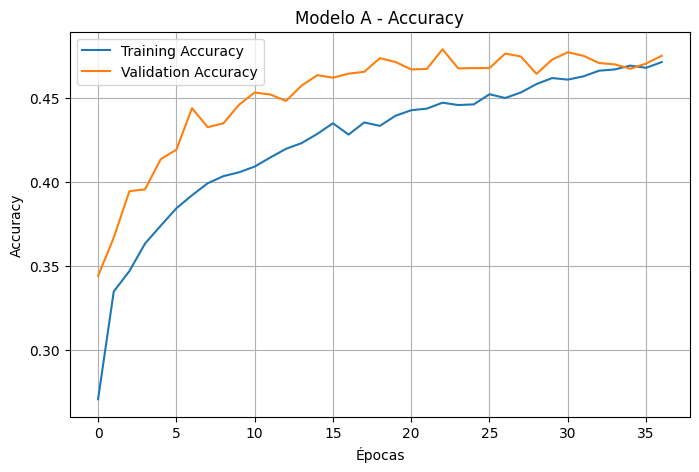

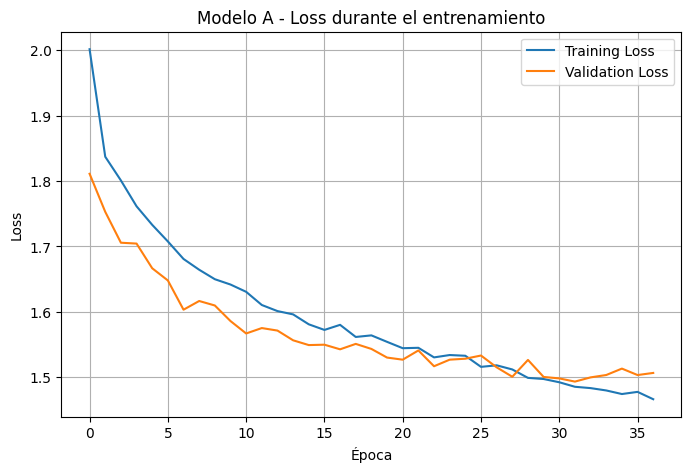

In [115]:
import matplotlib.pyplot as plt

def plot_training_curves(history, model_name="Modelo"):
  """
  Función genérica para graficar curvas de entrenamiento de un modelo de TensorFlow.

  Parámetros:
  -----------
  history : keras.callbacks.History
      Objeto History devuelto por model.fit()
  model_name : str
      Nombre del modelo para mostrar en los títulos (ej: "A", "B", "MLP", etc.)
  """

  # Gráfico de Accuracy
  plt.figure(figsize=(8, 5))

  plt.plot(history.history["accuracy"], label="Training Accuracy")
  plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

  plt.title(f"Modelo {model_name} - Accuracy")
  plt.xlabel("Épocas")
  plt.ylabel("Accuracy")
  plt.legend()
  plt.grid(True)
  plt.show()

  # Gráfico de Loss
  plt.figure(figsize=(8, 5))

  plt.plot(history.history['loss'], label='Training Loss')
  plt.plot(history.history['val_loss'], label='Validation Loss')

  plt.title(f"Modelo {model_name} - Loss durante el entrenamiento")
  plt.xlabel('Época')
  plt.ylabel('Loss')
  plt.legend()
  plt.grid(True)
  plt.show()

  return None

# Para el Modelo A
plot_training_curves(history_a, "A")

In [116]:
best_epoch = np.argmin(history_a.history['val_loss']) + 1
best_val_loss = min(history_a.history['val_loss'])
best_val_acc = history_a.history['val_accuracy'][best_epoch - 1]

print(f"Mejor época según val_loss: {best_epoch}")
print(f"Mejor Validation Loss: {best_val_loss:.4f}")
print(f"Validation Accuracy en esa época: {best_val_acc:.4f}")

Mejor época según val_loss: 32
Mejor Validation Loss: 1.4933
Validation Accuracy en esa época: 0.4749


### Interpretación inicial

Las curvas permiten observar la evolución del aprendizaje del modelo. Si la exactitud de entrenamiento aumenta mientras la exactitud de validación se estanca o disminuye, puede existir sobreajuste. De forma similar, si la pérdida de entrenamiento disminuye pero la pérdida de validación comienza a aumentar, el modelo está aprendiendo patrones específicos del conjunto de entrenamiento que no generalizan correctamente.

En este primer modelo, las curvas servirán como referencia para comparar arquitecturas posteriores.

---
## Experimentación con modelos adicionales

Después de entrenar el modelo base, se probarán nuevas configuraciones de MLP modificando la capacidad del modelo y su regularización. El objetivo no es elegir un modelo por intuición, sino comparar su desempeño con base en métricas de entrenamiento y validación.

Para mantener el código ordenado y reproducible, se definirá una función que permita construir modelos con diferentes números de capas, neuronas y valores de Dropout.

In [127]:
# Creamos una función para construir modelos

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

from tensorflow.keras.layers import Dense, Dropout, BatchNormalization

def build_mlp(
    hidden_layers,
    dropout_rate=0.3,
    use_batchnorm=False,
    input_dim=3072,
    num_classes=10
):

    model = Sequential()

    # Primera capa
    model.add(
        Dense(
            hidden_layers[0],
            activation='relu',
            input_shape=(input_dim,)
        )
    )

    if use_batchnorm:
        model.add(BatchNormalization())

    if dropout_rate > 0:
        model.add(Dropout(dropout_rate))

    # Capas restantes
    for units in hidden_layers[1:]:

        model.add(
            Dense(
                units,
                activation='relu'
            )
        )

        if use_batchnorm:
            model.add(BatchNormalization())

        if dropout_rate > 0:
            model.add(Dropout(dropout_rate))

    model.add(
        Dense(
            num_classes,
            activation='softmax'
        )
    )

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model


### Modelo B: MLP con mayor capacidad

El Modelo B aumenta la cantidad de neuronas y capas ocultas respecto al modelo base. La intención es evaluar si una red con mayor capacidad puede aprender representaciones más complejas de CIFAR-10.

Sin embargo, al aumentar el número de parámetros también aumenta el riesgo de sobreajuste.

In [118]:
# Ejecutamos nuestra función para declarar el modelo
model_b = build_mlp(
    hidden_layers=[1024, 512, 256],
    dropout_rate=0.3
)

model_b.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_23 (Dense)                │ (None, 1024)           │     3,146,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,805,450 (14.52 MB)

 Trainable params: 3,805,450 (14.52 MB)

 Non-trainable params: 0 (0.00 B)

In [119]:
# Definimos el earlystop para este modelo
early_stop_b = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# Entrenamos el modelo B
history_b = model_b.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=128,
    callbacks=[early_stop_b],
    verbose=1
)

Epoch 1/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.2315 - loss: 2.0903 - val_accuracy: 0.3103 - val_loss: 1.8942
Epoch 2/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.2994 - loss: 1.9144 - val_accuracy: 0.3416 - val_loss: 1.8247
Epoch 3/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.3173 - loss: 1.8621 - val_accuracy: 0.3692 - val_loss: 1.7819
Epoch 4/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.3257 - loss: 1.8318 - val_accuracy: 0.3827 - val_loss: 1.7548
Epoch 5/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.3347 - loss: 1.8110 - val_accuracy: 0.3509 - val_loss: 1.7934
Epoch 6/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.3460 - loss: 1.7870 - val_accuracy: 0.4012 - val_loss: 1.7007
Epoch 7/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.3606 - loss: 1.7569 - val_accuracy: 0.4003 - val_loss: 1.6860
Epoch 8/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.3660 - loss: 1.7430 - val_accuracy: 0

Modelo B - Validation Accuracy: 0.4591
Modelo B - Validation Loss: 1.5284


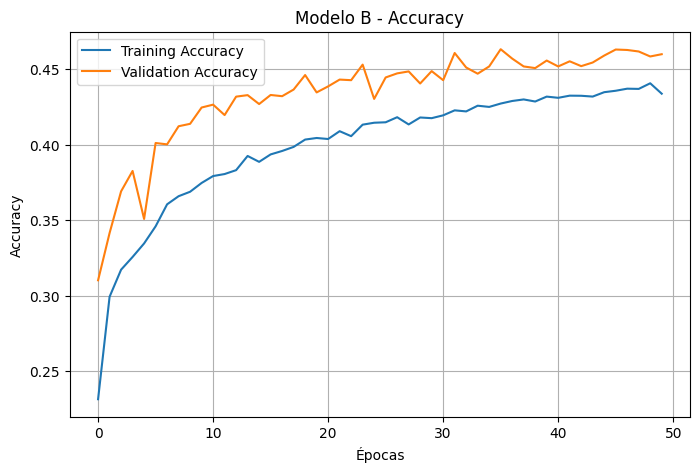

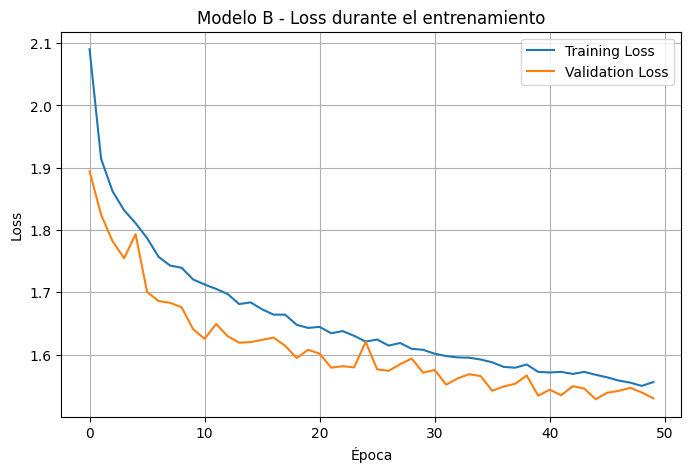


Mejor época según val_loss: 45
Mejor Validation Loss: 1.5284
Validation Accuracy en esa época: 0.4591


In [120]:
# Revisamos los resultados

val_loss_b, val_acc_b = model_b.evaluate(X_val, y_val, verbose=0)

print(f"Modelo B - Validation Accuracy: {val_acc_b:.4f}")
print(f"Modelo B - Validation Loss: {val_loss_b:.4f}")

# Llamamos la función para mostrar las curvas
plot_training_curves(history_b, "B")

# Vemos cuál fue la mejor época
best_epoch_b = np.argmin(history_b.history['val_loss']) + 1
best_val_loss_b = min(history_b.history['val_loss'])
best_val_acc_b = history_b.history['val_accuracy'][best_epoch_b - 1]

print(f"\nMejor época según val_loss: {best_epoch_b}")
print(f"Mejor Validation Loss: {best_val_loss_b:.4f}")
print(f"Validation Accuracy en esa época: {best_val_acc_b:.4f}")


---
### Modelo C: MLP con mayor regularización

El Modelo C conserva una arquitectura similar al modelo base, pero aumenta la tasa de Dropout. El propósito de este experimento es analizar si una regularización más fuerte mejora la generalización del modelo sobre el conjunto de validación.

Este modelo puede reducir el sobreajuste, aunque también existe el riesgo de limitar demasiado la capacidad de aprendizaje.

In [121]:
model_c = build_mlp(
    hidden_layers=[512, 256],
    dropout_rate=0.5
)

model_c.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_27 (Dense)                │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,707,274 (6.51 MB)

 Trainable params: 1,707,274 (6.51 MB)

 Non-trainable params: 0 (0.00 B)

In [122]:
early_stop_c = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

history_c = model_c.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=128,
    callbacks=[early_stop_c],
    verbose=1
)

Epoch 1/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.1859 - loss: 2.1633 - val_accuracy: 0.3004 - val_loss: 1.9683
Epoch 2/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.2180 - loss: 2.0429 - val_accuracy: 0.2894 - val_loss: 1.9530
Epoch 3/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.2347 - loss: 2.0197 - val_accuracy: 0.3082 - val_loss: 1.9483
Epoch 4/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.2456 - loss: 1.9918 - val_accuracy: 0.3252 - val_loss: 1.9294
Epoch 5/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.2562 - loss: 1.9714 - val_accuracy: 0.3349 - val_loss: 1.9079
Epoch 6/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.2605 - loss: 1.9659 - val_accuracy: 0.3397 - val_loss: 1.9117
Epoch 7/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.2684 - loss: 1.9419 - val_accuracy: 0.3328 - val_loss: 1.8979
Epoch 8/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.2690 - loss: 1.9470 - val_accuracy: 0

Modelo B - Validation Accuracy: 0.3328
Modelo B - Validation Loss: 1.8979


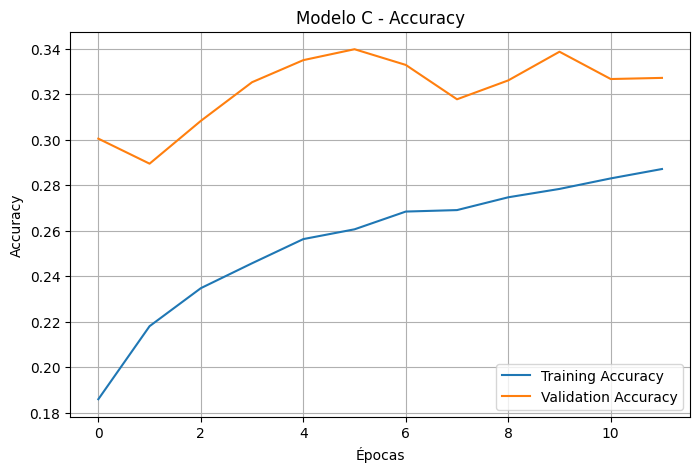

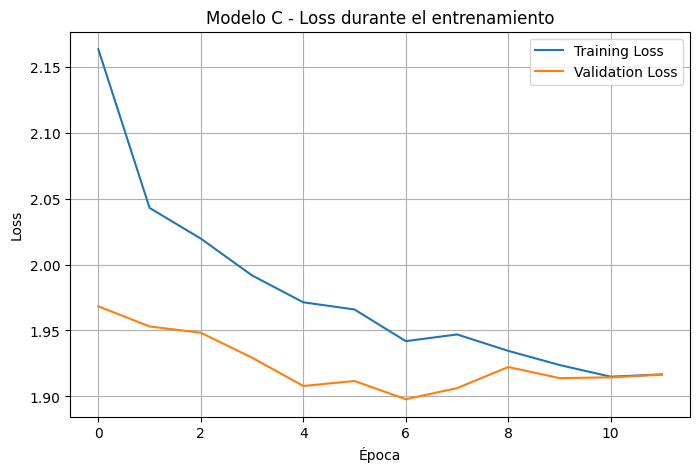


Mejor época según val_loss: 7
Mejor Validation Loss: 1.8979
Validation Accuracy en esa época: 0.3328


In [123]:
# Revisamos los resultados

val_loss_c, val_acc_c = model_c.evaluate(X_val, y_val, verbose=0)

print(f"Modelo B - Validation Accuracy: {val_acc_c:.4f}")
print(f"Modelo B - Validation Loss: {val_loss_c:.4f}")

# Llamamos la función para mostrar las curvas
plot_training_curves(history_c, "C")

# Vemos cuál fue la mejor época
best_epoch_c = np.argmin(history_c.history['val_loss']) + 1
best_val_loss_c = min(history_c.history['val_loss'])
best_val_acc_c = history_c.history['val_accuracy'][best_epoch_c - 1]

print(f"\nMejor época según val_loss: {best_epoch_c}")
print(f"Mejor Validation Loss: {best_val_loss_c:.4f}")
print(f"Validation Accuracy en esa época: {best_val_acc_c:.4f}")


### Comparación preliminar


In [124]:
results = {
    "Modelo": ["A - Baseline", "B - Mayor capacidad", "C - Mayor regularización"],
    "Validation Accuracy": [val_acc, val_acc_b, val_acc_c],
    "Validation Loss": [val_loss, val_loss_b, val_loss_c],
    "Épocas entrenadas": [
        len(history_a.history['loss']),
        len(history_b.history['loss']),
        len(history_c.history['loss'])
    ]
}

import pandas as pd

results_df = pd.DataFrame(results)
results_df

results_df.sort_values(by="Validation Accuracy", ascending=False)

,Modelo,Validation Accuracy,Validation Loss,Épocas entrenadas
0,A - Baseline,0.4749,1.493322,37
1,B - Mayor capacidad,0.4591,1.528418,50
2,C - Mayor regularización,0.3328,1.897877,12


In [131]:
# Probaremos un último modelo con normalización y menos drropout

model_d = build_mlp(
    hidden_layers=[512, 256],
    dropout_rate=0.3,
    use_batchnorm=True
)

early_stop_d = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

model_d.summary()

history_d = model_d.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=128,
    callbacks=[early_stop_d],
    verbose=1
)


Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_36 (Dense)                │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,710,346 (6.52 MB)

 Trainable params: 1,708,810 (6.52 MB)

 Non-trainable params: 1,536 (6.00 KB)

Epoch 1/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - accuracy: 0.3184 - loss: 2.0145 - val_accuracy: 0.3238 - val_loss: 1.9274
Epoch 2/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.3823 - loss: 1.7435 - val_accuracy: 0.3295 - val_loss: 1.8982
Epoch 3/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4118 - loss: 1.6541 - val_accuracy: 0.3505 - val_loss: 1.8287
Epoch 4/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4262 - loss: 1.6171 - val_accuracy: 0.2989 - val_loss: 1.9975
Epoch 5/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4327 - loss: 1.5925 - val_accuracy: 0.4056 - val_loss: 1.6612
Epoch 6/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4448 - loss: 1.5584 - val_accuracy: 0.3993 - val_loss: 1.6816
Epoch 7/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.4524 - loss: 1.5431 - val_accuracy: 0.4364 - val_loss: 1.5908
Epoch 8/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.4552 - loss: 1.5310 - val_accuracy: 0

Modelo D - Validation Accuracy: 0.4876
Modelo D - Validation Loss: 1.4634


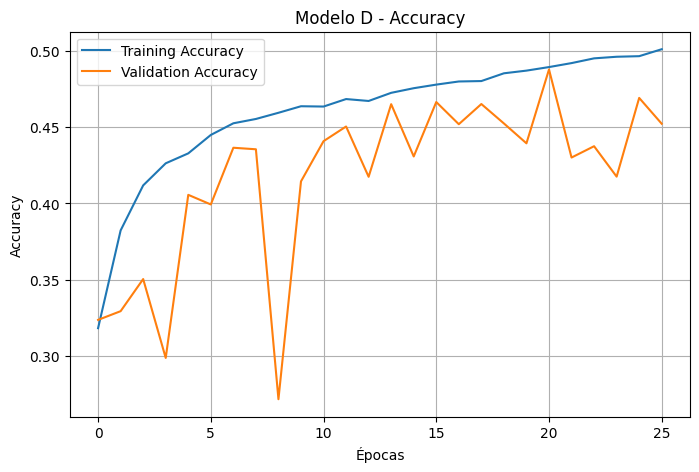

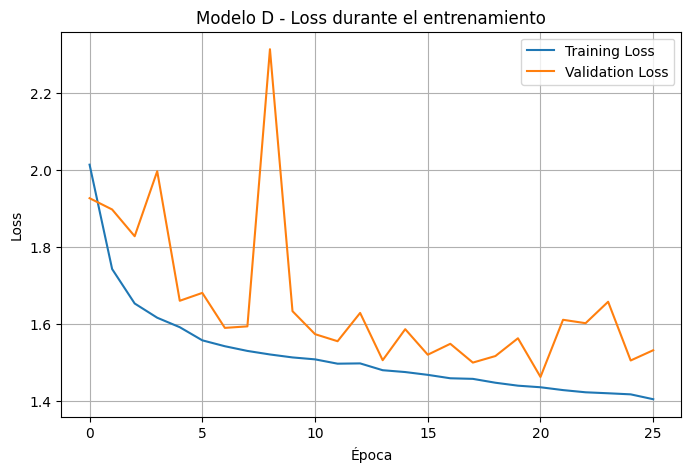


Mejor época según val_loss: 21
Mejor Validation Loss: 1.4634
Validation Accuracy en esa época: 0.4876


In [132]:
# Revisamos los resultados

val_loss_d, val_acc_d = model_d.evaluate(X_val, y_val, verbose=0)

print(f"Modelo D - Validation Accuracy: {val_acc_d:.4f}")
print(f"Modelo D - Validation Loss: {val_loss_d:.4f}")

# Llamamos la función para mostrar las curvas
plot_training_curves(history_d, "D")

# Vemos cuál fue la mejor época
best_epoch_d = np.argmin(history_d.history['val_loss']) + 1
best_val_loss_d = min(history_d.history['val_loss'])
best_val_acc_d = history_d.history['val_accuracy'][best_epoch_d - 1]

print(f"\nMejor época según val_loss: {best_epoch_d}")
print(f"Mejor Validation Loss: {best_val_loss_d:.4f}")
print(f"Validation Accuracy en esa época: {best_val_acc_d:.4f}")


### Análisis del Modelo D

El Modelo D incorporó Batch Normalization manteniendo la misma arquitectura general del Modelo A y una tasa de Dropout de 0.3. Esta modificación permitió obtener una mejora ligera pero consistente sobre el conjunto de validación.

En comparación con el Modelo A, el Modelo D aumentó la exactitud de validación y redujo la pérdida de validación. Esto indica que la normalización por lotes contribuyó a estabilizar el entrenamiento y mejorar ligeramente la capacidad de generalización del modelo.

Aunque la mejora no es muy grande, resulta relevante porque se obtuvo sin aumentar significativamente la complejidad de la arquitectura. Por ello, el Modelo D se considera hasta este punto como la mejor configuración experimental.

In [133]:
results = {
    "Modelo": [
        "A - Baseline",
        "B - Mayor capacidad",
        "C - Mayor regularización",
        "D - BatchNorm + Dropout"
    ],
    "Validation Accuracy": [
        val_acc,
        val_acc_b,
        val_acc_c,
        val_acc_d
    ],
    "Validation Loss": [
        val_loss,
        val_loss_b,
        val_loss_c,
        val_loss_d
    ],
    "Épocas entrenadas": [
        len(history_a.history['loss']),
        len(history_b.history['loss']),
        len(history_c.history['loss']),
        len(history_d.history['loss'])
    ]
}

results_df = pd.DataFrame(results)
results_df.sort_values(by="Validation Accuracy", ascending=False)

,Modelo,Validation Accuracy,Validation Loss,Épocas entrenadas
3,D - BatchNorm + Dropout,0.4876,1.463406,26
0,A - Baseline,0.4749,1.493322,37
1,B - Mayor capacidad,0.4591,1.528418,50
2,C - Mayor regularización,0.3328,1.897877,12


## Evaluación final sobre el conjunto de prueba

Después de comparar las diferentes configuraciones experimentales utilizando el conjunto de validación, se seleccionó el Modelo D como la mejor arquitectura.

Para obtener una estimación imparcial de su capacidad de generalización, se evaluará el modelo sobre el conjunto de prueba, el cual no participó en ninguna etapa de entrenamiento ni selección de hiperparámetros.

In [134]:
test_loss, test_acc = model_d.evaluate(
    X_test,
    y_test,
    verbose=0
)

print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")

Test Accuracy: 0.4914
Test Loss: 1.4369


In [140]:
y_pred_prob = model_d.predict(X_test)

y_pred = np.argmax(
    y_pred_prob,
    axis=1
)

y_true = np.argmax(
    y_test,
    axis=1
)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [141]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(
    y_true,
    y_pred
)

<Figure size 1000x800 with 0 Axes>

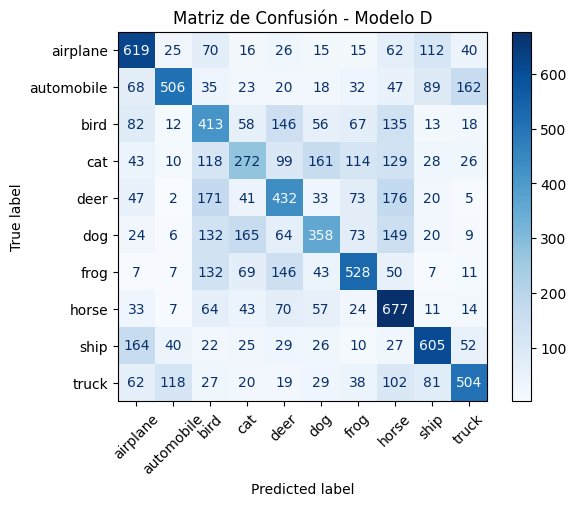

In [142]:
plt.figure(figsize=(10,8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(
    xticks_rotation=45,
    cmap="Blues"
)

plt.title("Matriz de Confusión - Modelo D")
plt.show()

In [143]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

    airplane       0.54      0.62      0.58      1000
  automobile       0.69      0.51      0.58      1000
        bird       0.35      0.41      0.38      1000
         cat       0.37      0.27      0.31      1000
        deer       0.41      0.43      0.42      1000
         dog       0.45      0.36      0.40      1000
        frog       0.54      0.53      0.53      1000
       horse       0.44      0.68      0.53      1000
        ship       0.61      0.60      0.61      1000
       truck       0.60      0.50      0.55      1000

    accuracy                           0.49     10000
   macro avg       0.50      0.49      0.49     10000
weighted avg       0.50      0.49      0.49     10000



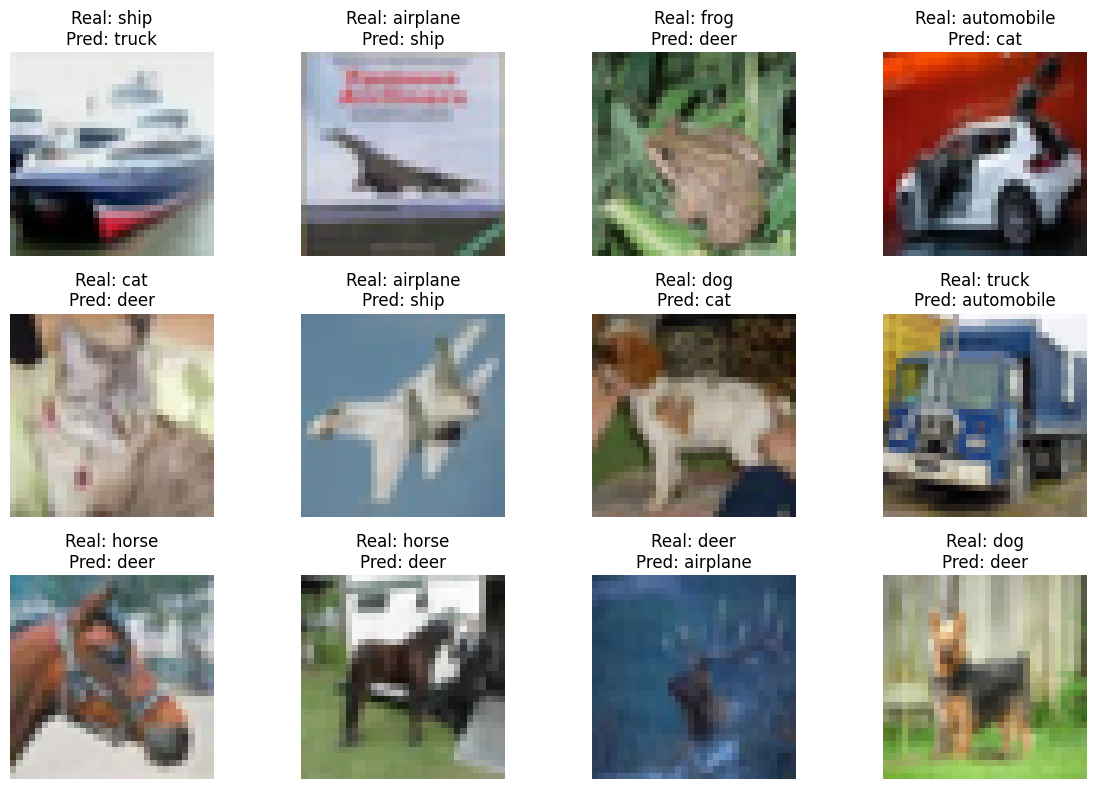

In [145]:
incorrect = np.where(
    y_pred != y_true
)[0]

plt.figure(figsize=(12,8))

for i, idx in enumerate(incorrect[:12]):

    plt.subplot(3,4,i+1)

    image = X_test[idx].reshape(32,32,3)

    plt.imshow(image)

    plt.title(
        f"Real: {class_names[y_true[idx]]}\nPred: {class_names[y_pred[idx]]}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()